__Базовая информация про relationship__

__Введение в RELATIONSHIP - вся МОЩЬ ORM__

Алхимия предлагает соединять разные модели друг с другом следующим образом:



Просто указываем название класса:

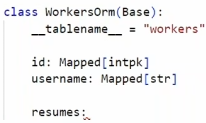

лучше указывать в кавычках (чтобы избежать проблем с импортами)

Тоже самое сделаем и для воркеров:



В данном случае у нас возникает n+1 проблема:

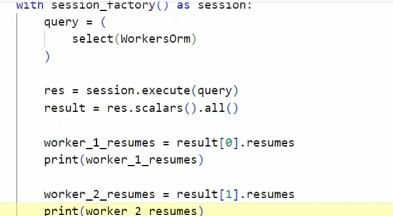

где n - колчиество рабочих

В данном коде возникает проблема "n+1" из-за "lazy-загрузки" (ленивой загрузки) отношения resumes.

Вот как это происходит:

1.  Первичный запрос: Запрос select(WorkersOrm) извлекает информацию о всех работниках из базы данных. Это, по сути, "n" запросов.

2.  Ленивая загрузка resumes: Отношение resumes в WorkersOrm настроено на ленивую загрузку.  Это означает, что данные о резюме каждого работника не загружаются при первоначальном запросе.

3.  Доступ к resumes:

•   Когда код обращается к result[0].resumes (резюме первого работника), SQLAlchemy делает отдельный запрос к базе данных, чтобы получить данные о резюме этого конкретного работника. Это первый "+1" запрос.

•   Когда код обращается к result[1].resumes (резюме второго работника), SQLAlchemy делает еще один отдельный запрос к базе данных, чтобы получить данные о резюме этого конкретного работника.  Это второй "+1" запрос.

В итоге, если у вас есть, например, 10 работников, вы выполните 1 запрос для получения данных о работниках (первоначальный запрос) + 10 запросов для получения резюме каждого из них (10 × 1 = 10).  Общее количество запросов будет 11, а не 1, как могло бы быть, если бы данные о резюме были загружены вместе с данными о работниках.

Чтоб решить эту проблему нужно использовать joinload или selectionload

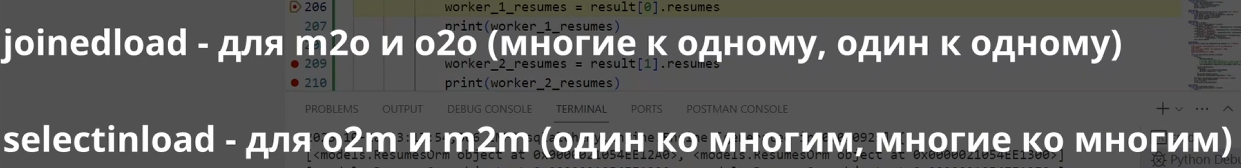

Как красиво выводить параметры на печать

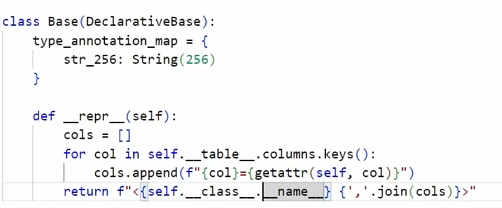

В async алхимии нельзя использовать ленивую подгрузку

__Продвинутые RELATIONSHIP + индексы и constraints на уровне БД__

Чтоб правильно задать relationship -> нужно показать алхимии, что эти связи друг на друга ссылаются, то есть



ссылается на ResumesOrm, а



ссылается на WorkersOrm

это задаеися с помощью back_populates:

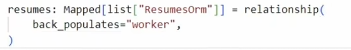

backref - неявное указание на другую relationship

Чтоб подгрузить несколько relationship'ов нужно использовать options

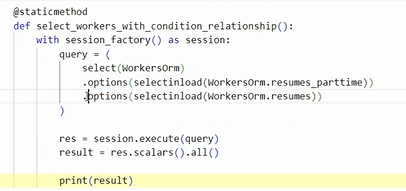

параметр lazy отвечает за подгрузку и если его указать, то options писать не надо, но рекомендуется указывать options и делать все явно

contains_eager() используется для предварительной загрузки отношений (eager loading) с уже загруженными данными, когда JOIN уже выполнен вручную. Когда вы делаете JOIN в запросе, но не используете joinedload, SQLAlchemy все равно может выполнить дополнительный запрос для загрузки связанных данных. contains_eager предотвращает это.

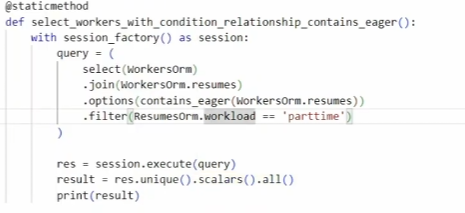

Пример как выбирать единичные экземпляра.

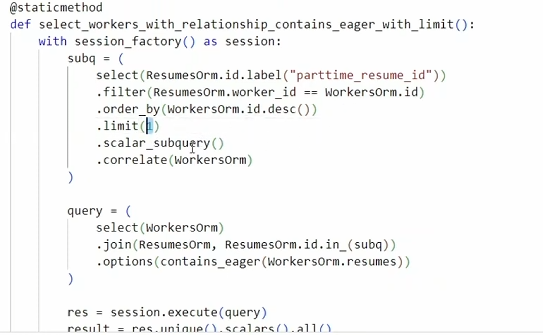

за кол-во отвеает limit, scalar_subquery возвращает значение

Индексы можно задавать в атрибуте __table_args__ (он есть в каждой модели)

Внешние и первичные ключи рекомендуется оставлять возле столбов, а всякие индексы и констрейнты стоить вносить

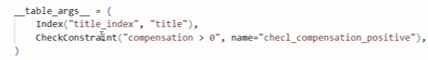

__Многие-ко-Многим в SQLAlchemy - Как Сделать m2m связь__

Создадим модель вакансий:

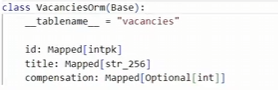

Чтобы связать модель резюме и вакансий (many to many) можно создать класс

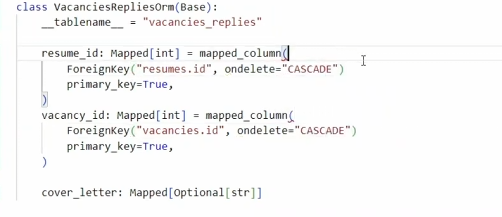

А затем связать их, мы берем уже созданную нужную таблицу например с Вакансиями и связываем ее через вторую таблицу (many to many), указываеся ее в secondary

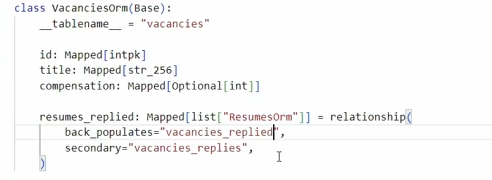

Тоже самое делаем и для резюме